# It have used the ResNet50 pretrained model 

In [5]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

PIL.AvifImagePlugin.AvifImageFile

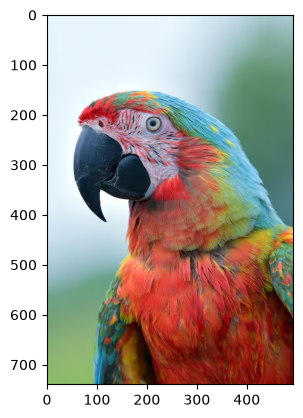

In [6]:
from keras.preprocessing import image
import matplotlib.pyplot as plt
img_p = image.load_img(r"C:\Users\rkmou\OneDrive\Desktop\jypter\parrot.jpg")
plt.imshow(img_p)
type(img_p)

In [7]:
model = ResNet50(weights='imagenet')

In [11]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [8]:
img_path = r'C:\Users\rkmou\OneDrive\Desktop\jypter\parrot.jpg'

img = keras.utils.load_img(img_path, target_size=(224, 224))# target_size=(224, 224) resizes the image to 224 × 224 pixels.

x = keras.utils.img_to_array(img)
#⬆️Convert the PIL image into a NumPy array.
# A computer model cannot directly work with the image object.
# The image is converted into numerical pixel values.
# For an RGB image, the shape becomes:
# (224, 224, 3)
# 224 = height
# 224 = width
# 3 = RGB color channels

x = np.expand_dims(x, axis=0)
#⬆️ After this step:
# Shape = (1, 224, 224, 3)
#
# 1 means we are giving the model one image.
# Neural networks generally expect input in batches.

x = preprocess_input(x)

#Preprocess the image according to the pretrained model.   
# preprocess_input() performs the preprocessing expected by the
# particular pretrained CNN model.
# Depending on the model, this may include operations such as:
# - Scaling pixel values
# - Normalizing pixel values
# - Changing RGB/BGR channel order
# This makes the image format compatible with the pretrained model.

In [9]:
type(img_path) # path should be path-like or io.BytesIO, not <class 'PIL.AvifImagePlugin.AvifImageFile'> 
#path should in accepted in the string not PIL.AvifImagePlugin.AvifImageFile

str

In [10]:
preds = model.predict(x)

print('Predicted:', decode_predictions(preds, top=3)[0])

#Convert the prediction numbers into readable class names.
# decode_predictions() takes the model's output and converts the
# class IDs into human-readable labels.
# top=3 means:
# Show the 3 classes with the highest prediction scores.
# [0] selects the predictions for the first image in the batch

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted: [('n01818515', 'macaw', np.float32(0.8771141)), ('n01820546', 'lorikeet', np.float32(0.0976442)), ('n01828970', 'bee_eater', np.float32(0.020895617))]


**It donot print like parrot, butterfly , it also tells the species like in butterfly what or in parrot like what species  macaw and it give the top 3 result if u set it to the 1 it only give it one and what chance of the being that species in the np.float like 87 % or 9% if u set it to 2 or 3 or ...** 